In [1]:
# Install dependencies
!pip install prophet lightgbm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from lightgbm import LGBMRegressor

In [3]:
!pip install pyarrow

import pandas as pd

url = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2020-01.parquet"

df = pd.read_parquet(url)

# Keep only relevant columns for analytics
df = df[['tpep_pickup_datetime', 'tpep_dropoff_datetime',
         'passenger_count', 'trip_distance',
         'PULocationID', 'DOLocationID', 'total_amount']]

df = df.dropna()

print(df.head())
print(df.shape)

  tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  trip_distance  \
0  2020-01-01 00:28:15   2020-01-01 00:33:03              1.0            1.2   
1  2020-01-01 00:35:39   2020-01-01 00:43:04              1.0            1.2   
2  2020-01-01 00:47:41   2020-01-01 00:53:52              1.0            0.6   
3  2020-01-01 00:55:23   2020-01-01 01:00:14              1.0            0.8   
4  2020-01-01 00:01:58   2020-01-01 00:04:16              1.0            0.0   

   PULocationID  DOLocationID  total_amount  
0           238           239         11.27  
1           239           238         12.30  
2           238           238         10.80  
3           238           151          8.16  
4           193           193          4.80  
(6339567, 7)


In [4]:
# STEP 2: FEATURE ENGINEERING
df['date'] = df['tpep_pickup_datetime'].dt.date
df['hour'] = df['tpep_pickup_datetime'].dt.hour
df['day_of_week'] = df['tpep_pickup_datetime'].dt.dayofweek

# Aggregate demand (simulate shipments)
demand_df = df.groupby('date').size().reset_index(name='shipments')
demand_df.columns = ['ds', 'y']

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


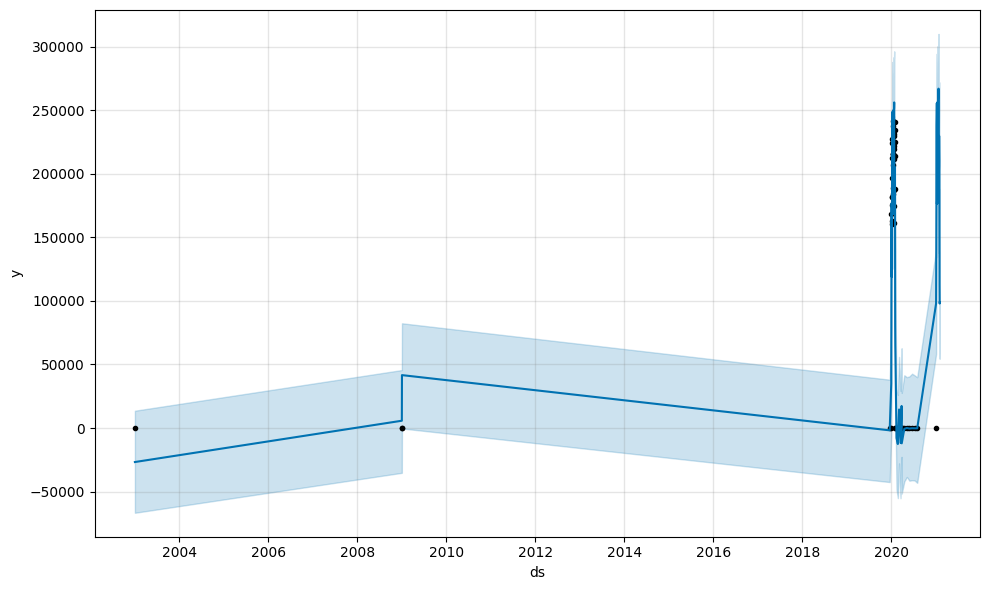

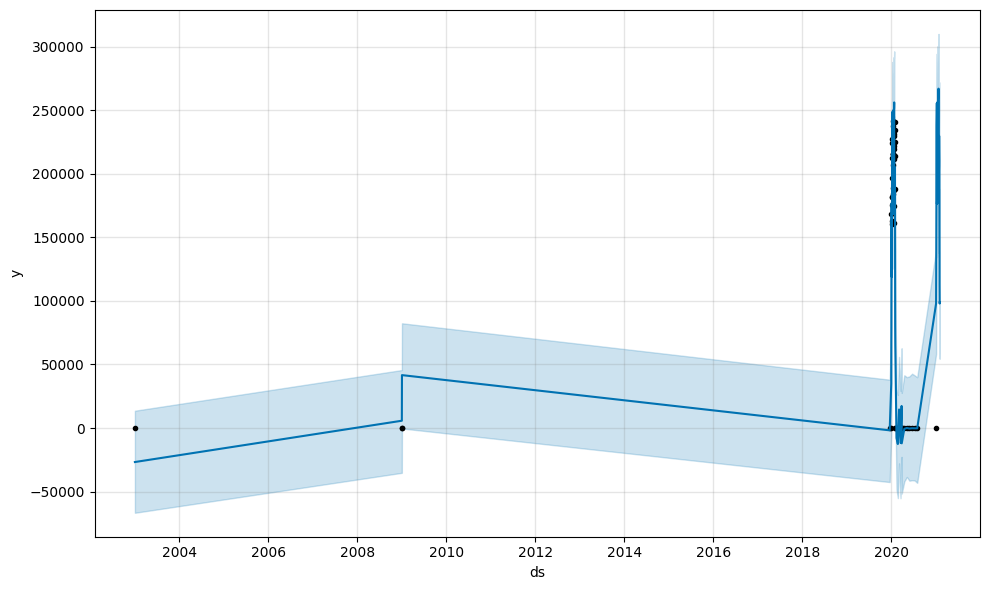

In [5]:
# STEP 3: FORECASTING (PROPHET)

model = Prophet()
model.fit(demand_df)

future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

# Plot forecast
model.plot(forecast)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.112432 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 294
[LightGBM] [Info] Number of data points in the train set: 6339567, number of used features: 4
[LightGBM] [Info] Start training from score 1.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain

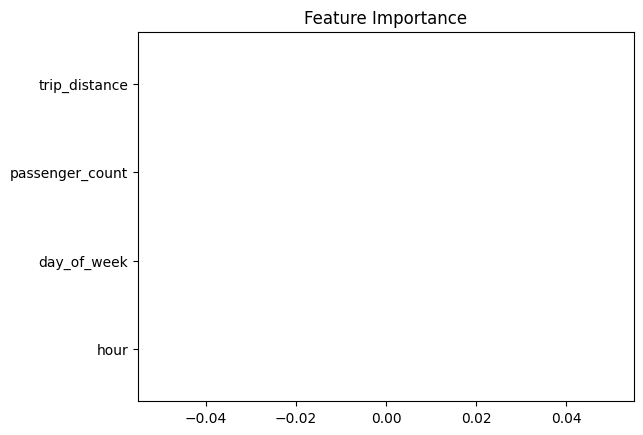

In [6]:
# STEP 4: MACHINE LEARNING MODEL

df_ml = df.copy()

df_ml['target'] = 1  # each row = shipment

features = ['hour', 'day_of_week', 'passenger_count', 'trip_distance']
df_ml = df_ml.dropna(subset=features)

X = df_ml[features]
y = df_ml['target']

model_lgb = LGBMRegressor()
model_lgb.fit(X, y)

# Feature importance
import matplotlib.pyplot as plt
plt.barh(features, model_lgb.feature_importances_)
plt.title("Feature Importance")
plt.show()

In [7]:
# STEP 5: DEMAND HOTSPOTS

zone_demand = df.groupby('PULocationID').size().reset_index(name='demand')

zone_demand = zone_demand.sort_values(by='demand', ascending=False)

print(zone_demand.head())

     PULocationID  demand
231           237  292467
156           161  281545
230           236  271999
157           162  235024
181           186  228231


In [9]:
# STEP 6: SIMPLE ROUTE OPTIMIZATION LOGIC

# Simulated cost function

def calculate_cost(distance, demand):
    return distance * 0.5 + demand * 0.3

df['cost'] = calculate_cost(df['trip_distance'], 1)

optimized_routes = df.sort_values(by='cost').head(10)

print(optimized_routes[['trip_distance', 'cost']].head())

         trip_distance    cost
957569          -22.18 -10.790
1355713         -10.94  -5.170
787926           -9.29  -4.345
1818638          -6.40  -2.900
1275502          -6.33  -2.865
